In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

In [4]:
df = pd.read_csv('../data/data12.csv') 

df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
df = df.drop(columns=['id','Unnamed: 32'])
df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [6]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [9]:
ca = PCA(n_components=0.95)
X_train_pca = ca.fit_transform(X_train_s)
X_test_pca = ca.transform(X_test_s)

print("Jumlah komponen PCA:", ca.n_components_)


Jumlah komponen PCA: 10


In [10]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca,y_train)
y_pred_knn = knn.predict(X_test_pca)
print('Akurasi KNN:', accuracy_score(y_test,y_pred_knn))

Akurasi KNN: 0.956140350877193


In [11]:
# SVM
svm = SVC(kernel='rbf')
svm.fit(X_train_pca,y_train)
y_pred_svm = svm.predict(X_test_pca)
print('Akurasi SVM:', accuracy_score(y_test,y_pred_svm))

Akurasi SVM: 0.9649122807017544


In [12]:
# Naive Bayes
nb = GaussianNB()
nb.fit(X_train_pca,y_train)
y_pred_nb = nb.predict(X_test_pca)
print('Akurasi Naive Bayes:', accuracy_score(y_test,y_pred_nb))

Akurasi Naive Bayes: 0.8947368421052632


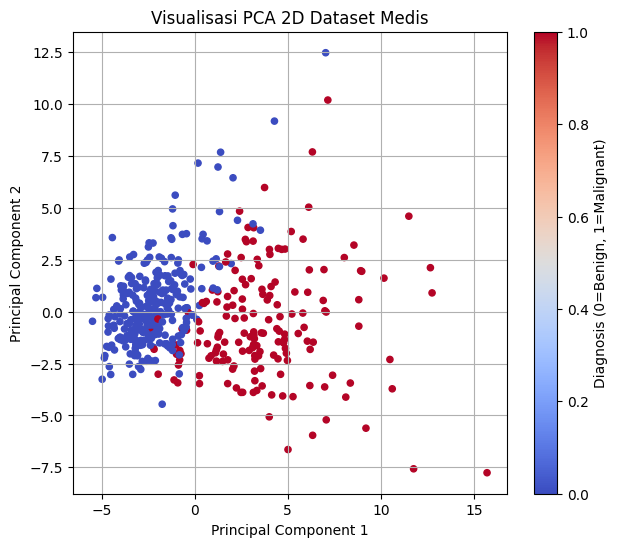

In [13]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train_s)

plt.figure(figsize=(7,6))
plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    c=y_train,
    cmap='coolwarm',
    s=20
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Visualisasi PCA 2D Dataset Medis")
plt.colorbar(label="Diagnosis (0=Benign, 1=Malignant)")
plt.grid(True)
plt.show()


In [14]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)

print("Jumlah komponen PCA:", pca.n_components_)


Jumlah komponen PCA: 10


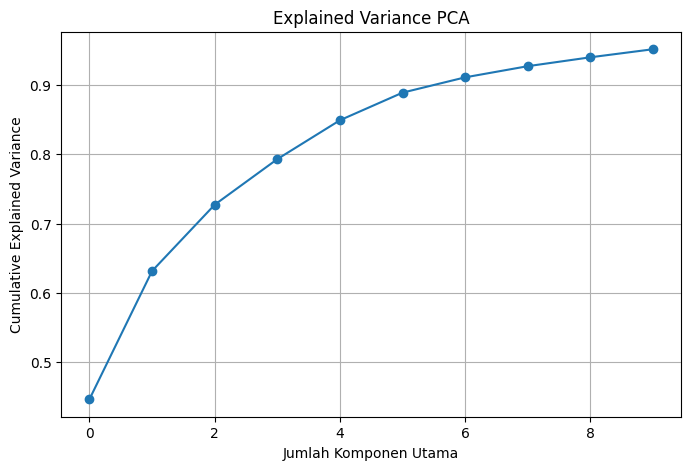

In [15]:
plt.figure(figsize=(8,5))
plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)
plt.xlabel("Jumlah Komponen Utama")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance PCA")
plt.grid(True)
plt.show()


In [16]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)
y_knn = knn.predict(X_test_pca)

# SVM
svm = SVC(kernel='rbf')
svm.fit(X_train_pca, y_train)
y_svm = svm.predict(X_test_pca)

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train_pca, y_train)
y_nb = nb.predict(X_test_pca)

print("Akurasi KNN:", accuracy_score(y_test, y_knn))
print("Akurasi SVM:", accuracy_score(y_test, y_svm))
print("Akurasi Naive Bayes:", accuracy_score(y_test, y_nb))


Akurasi KNN: 0.956140350877193
Akurasi SVM: 0.9649122807017544
Akurasi Naive Bayes: 0.8947368421052632


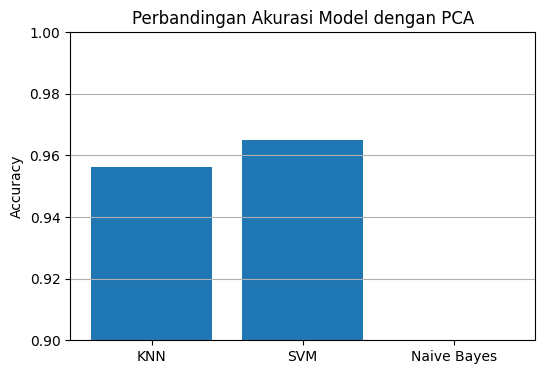

In [17]:
models = ['KNN', 'SVM', 'Naive Bayes']
accuracies = [
    accuracy_score(y_test, y_knn),
    accuracy_score(y_test, y_svm),
    accuracy_score(y_test, y_nb)
]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.ylim(0.9, 1.0)
plt.ylabel("Accuracy")
plt.title("Perbandingan Akurasi Model dengan PCA")
plt.grid(axis='y')
plt.show()
